## Random Extraction

In [ ]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)


import utils.pool_utils
from examples.mia.text_mia.tabds_handler import TABInputHandler
from leakpro.leakpro import LeakPro
config_path = "audit.yaml"

leakpro = LeakPro(TABInputHandler, config_path)
leakpro.run_audit()

2025-03-11 10:20:31,398 INFO     Target model blueprint created from TABBERT in ../mia/text_mia/utils/tabds_model_preparation.py.
2025-03-11 10:20:31,400 INFO     Loaded target model metadata from ./target/model_metadata.pkl
/home/amandus/msc-code/LeakPro/leakpro/input_handler/handler_setup.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weig

True Entity: CODE, True text:  36244/06
Five best guesses and weights in policy for player 0:
['13/2005, 0.01762958312708746', '1271/05, 0.015467201915224821', '38549/97, 0.015033717365819696', '8518/08, 0.010091357543017314', '24746/94, 0.009231311877408206']
True Entity: PERSON, True text:  Mr Henrik Hasslund
Five best guesses and weights in policy for player 1:
['Mr Hüsamettin Keskin, 0.0003681429340636814', 'Mr Hans-Konrad von Koester, 0.00036370355390716373', 'Mr A. Lynch, 0.0002077630264326591', 'Mrs B. Jovin Hrastnik, 0.0001960029172699174', 'Mr M. Fisher, 0.00018721030241968577']
True Entity: DATETIME, True text:  31 August 2006
Five best guesses and weights in policy for player 2:
['7 September 1995, 4.845513599869456e-05', '13 January 1994, 4.714254310399184e-05', '30 September 1991, 3.980977151642651e-05', 'winter of 2007, 3.978125450875517e-05', '16 April 2008, 3.958501300721961e-05']
True Entity: PERSON, True text:  Mr Tyge Trier
Five best guesses and weights in policy for

ValueError: Please provide the audit results

## Bandit extraction

In [1]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

sys.path.append(project_root)
#os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
#os.environ["TORCH_USE_CUDA_DSA"] = "1"

import utils.pool_utils
from examples.mia.text_mia.tabds_handler import TABInputHandler
from examples.mia.text_mia.utils.tabds_data_preparation import LabelSet
from leakpro.leakpro import LeakPro
config_path = "audit.yaml"


leakpro = LeakPro(TABInputHandler, config_path)
leakpro.run_audit()

/home/amandus/miniconda3/envs/leakpro/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-20 09:55:04,782 INFO     Target model blueprint created from TABBERT in ../mia/text_mia/utils/tabds_model_preparation.py.
2025-01-20 09:55:04,783 INFO     Loaded target model metadata from ./target/model_metadata.pkl
/home/amandus/msc-code/LeakPro/leakpro/input_handler/handler_setup.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`.

True Entity: CODE, True text:  36244/06
Five best guesses and weights in policy for player 0:
['33645/96, 0.0025869252220726818', '17584/04, 0.002484033550541616', '41721/04, 0.002463488375990169', '11106/04, 0.0024310029516509423', '10443/08, 0.0023205240304305617']
True Entity: PERSON, True text:  Mr Henrik Hasslund
Five best guesses and weights in policy for player 1:
['Mr J. Casadevall, 0.030069320011987633', 'Mr R. Bernhardt, 0.022389268230107447', 'Mr Tahery, 0.002237151324029793', 'Mr Müslüm Atasoy, 0.0007831218742096298', 'Mrs S. Botoucharova, 0.0005609977163230157']
True Entity: DATETIME, True text:  31 August 2006
Five best guesses and weights in policy for player 2:
['1930, 0.02228005498080551', '15 April 1999, 0.005938221326195855', '7 June 1990, 0.00259453866280744', 'July 1993 to March 1994, 0.0025420572439431165', '11 January 2002, 0.0025403563534948685']
True Entity: PERSON, True text:  Mr Tyge Trier
Five best guesses and weights in policy for player 3:
['Mr I. Foighel,

In [3]:
# Load the observations
import numpy as np
import matplotlib.pyplot as plt 


obs = np.load('./observations.npy')

In [35]:
max_reward[0:5]/n

array([0.54818034, 0.71378467, 0.78574909, 0.83820052, 0.8545889 ])

Text(0.5, 1.0, 'Maximum average reward, using random sampling')

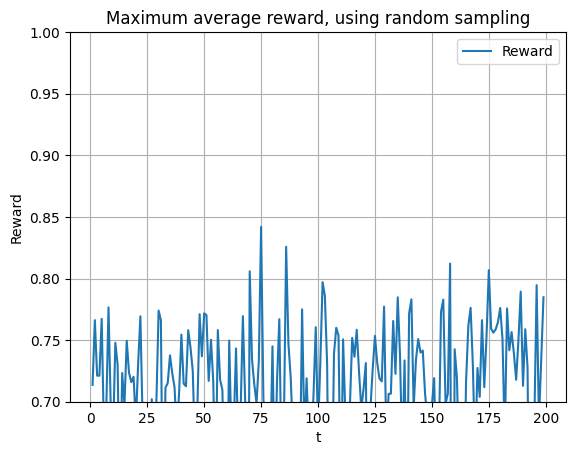

In [3]:
obs = np.load('./observations.npy')
T, n = obs.shape

max_reward = np.zeros(T-1)
for t in range(1,T):
    max_reward[t-1] = np.sum(obs[t,:]) # np.sum(np.max(obs[:t,:], axis = 0)) 

plt.plot(range(1, T), max_reward/n, label = "Reward")
plt.grid()
plt.legend()
plt.ylim([0.7, 1])
plt.xlabel('t')
plt.ylabel("Reward")
plt.title('Maximum average reward, using random sampling')

#plt.savefig('./random_reward.svg', format ="svg" )


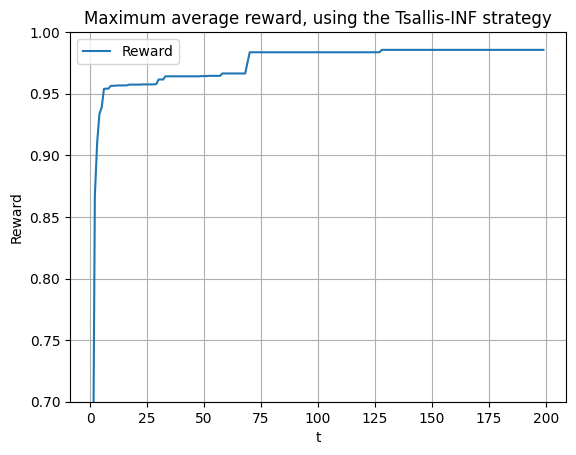

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

obs = np.load('./observations.npy')
T, n = obs.shape
strategy_string = "Tsallis-INF"

max_reward = np.zeros(T-1)
for t in range(1,T):
    max_reward[t-1] =np.sum(np.max(obs[:t,:], axis = 0)) 

plt.plot(range(1, T), max_reward/n, label = "Reward")
plt.grid()
plt.legend()
plt.ylim([0.7, 1])
plt.xlabel('t')
plt.ylabel("Reward")
plt.title(f'Maximum average reward, using the {strategy_string} strategy')
plt.show()
#plt.savefig('./tsallis_inf_reward_rf1.svg', format ="svg" )